# UCI Nursery Data Set - Comprehensive Visualization Analysis

This notebook performs comprehensive exploratory data analysis and visualization on the UCI Nursery Dataset, which contains information about nursery class evaluation.

## Section 1: Import Required Libraries

Import necessary libraries including pandas, numpy, matplotlib, seaborn, and plotly for data manipulation and visualization.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Section 2: Load the UCI Nursery Dataset

Load the UCI Nursery dataset from a CSV file into a pandas DataFrame. Set appropriate column names and data types.

In [12]:
# Load the dataset
file_path = 'nursery.csv'
df = pd.read_csv(file_path)

# Display basic info about the dataset
print(f"Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows of the dataset:")
print(df.head(10))

Dataset loaded successfully!
Dataset shape: (12960, 9)

First few rows of the dataset:
  parents has_nurs      form children     housing     finance         social  \
0   usual   proper  complete        1  convenient  convenient        nonprob   
1   usual   proper  complete        1  convenient  convenient        nonprob   
2   usual   proper  complete        1  convenient  convenient        nonprob   
3   usual   proper  complete        1  convenient  convenient  slightly_prob   
4   usual   proper  complete        1  convenient  convenient  slightly_prob   
5   usual   proper  complete        1  convenient  convenient  slightly_prob   
6   usual   proper  complete        1  convenient  convenient    problematic   
7   usual   proper  complete        1  convenient  convenient    problematic   
8   usual   proper  complete        1  convenient  convenient    problematic   
9   usual   proper  complete        1  convenient      inconv        nonprob   

        health final evaluation 

## Section 3: Explore Dataset Structure and Statistics

Display dataset shape, info(), describe(), and head() to understand the data structure, data types, missing values, and basic statistics.

In [13]:
# Display dataset information
print("Dataset Information:")
print(df.info())
print("\n" + "="*80 + "\n")

# Display statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*80 + "\n")

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80 + "\n")

# Display unique values for each column
print("Unique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   parents           12960 non-null  str  
 1   has_nurs          12960 non-null  str  
 2   form              12960 non-null  str  
 3   children          12960 non-null  str  
 4   housing           12960 non-null  str  
 5   finance           12960 non-null  str  
 6   social            12960 non-null  str  
 7   health            12960 non-null  str  
 8   final evaluation  12960 non-null  str  
dtypes: str(9)
memory usage: 911.4 KB
None


Statistical Summary:
       parents has_nurs      form children     housing     finance   social  \
count    12960    12960     12960    12960       12960       12960    12960   
unique       3        5         4        4           3           2        3   
top      usual   proper  complete        1  convenient  convenient  nonprob   
freq 

## Section 4: Data Cleaning and Preparation

Handle missing values, remove duplicates, and prepare data for visualization.

In [14]:
# Check for duplicates
print(f"Duplicates in dataset: {df.duplicated().sum()}")

# Remove any duplicates if present
df_clean = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df_clean.shape}")

# Check for any missing values
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

# Display the cleaned dataset info
print("\nCleaned Dataset Summary:")
print(f"Total records: {len(df_clean)}")
print(f"Total features: {len(df_clean.columns)}")
print(f"Features: {list(df_clean.columns)}")

Duplicates in dataset: 0
Dataset shape after removing duplicates: (12960, 9)
Missing values after cleaning: 0

Cleaned Dataset Summary:
Total records: 12960
Total features: 9
Features: ['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health', 'final evaluation']


## Section 5: Univariate Visualizations

Create bar charts to visualize individual features and their distributions.

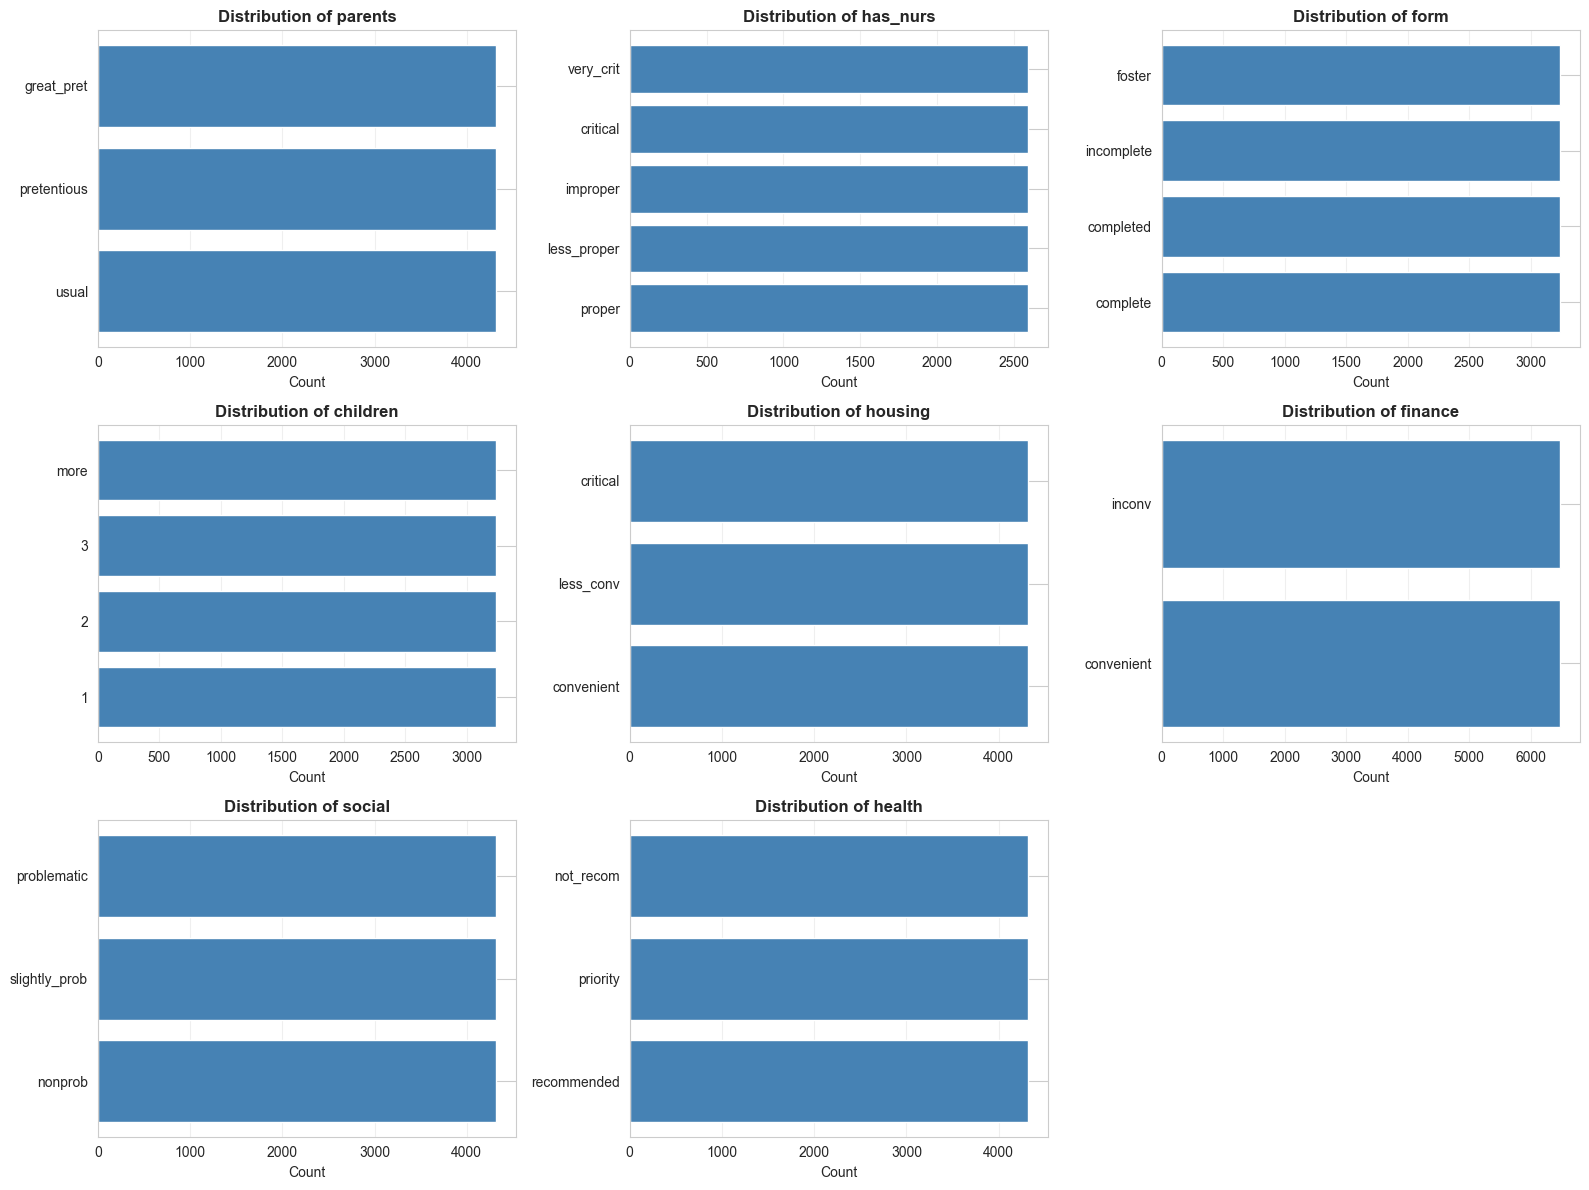

Value Counts Summary:

parents:
parents
usual          4320
pretentious    4320
great_pret     4320

has_nurs:
has_nurs
proper         2592
less_proper    2592
improper       2592
critical       2592
very_crit      2592

form:
form
complete      3240
completed     3240
incomplete    3240
foster        3240

children:
children
1       3240
2       3240
3       3240
more    3240

housing:
housing
convenient    4320
less_conv     4320
critical      4320

finance:
finance
convenient    6480
inconv        6480

social:
social
nonprob          4320
slightly_prob    4320
problematic      4320

health:
health
recommended    4320
priority       4320
not_recom      4320

final evaluation:
final evaluation
not_recom     4320
priority      4266
spec_prior    4044
very_recom     328
recommend        2


In [15]:
# Create subplots for univariate analysis
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(df_clean.columns):
    value_counts = df_clean[col].value_counts()
    axes[idx].barh(value_counts.index, value_counts.values, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel('Count')
    axes[idx].grid(axis='x', alpha=0.3)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Display count summaries
print("Value Counts Summary:")
print("="*80)
for col in df_clean.columns:
    print(f"\n{col}:")
    print(df_clean[col].value_counts().to_string())

## Section 6: Bivariate Visualizations

Create grouped bar charts to explore relationships between key variables.

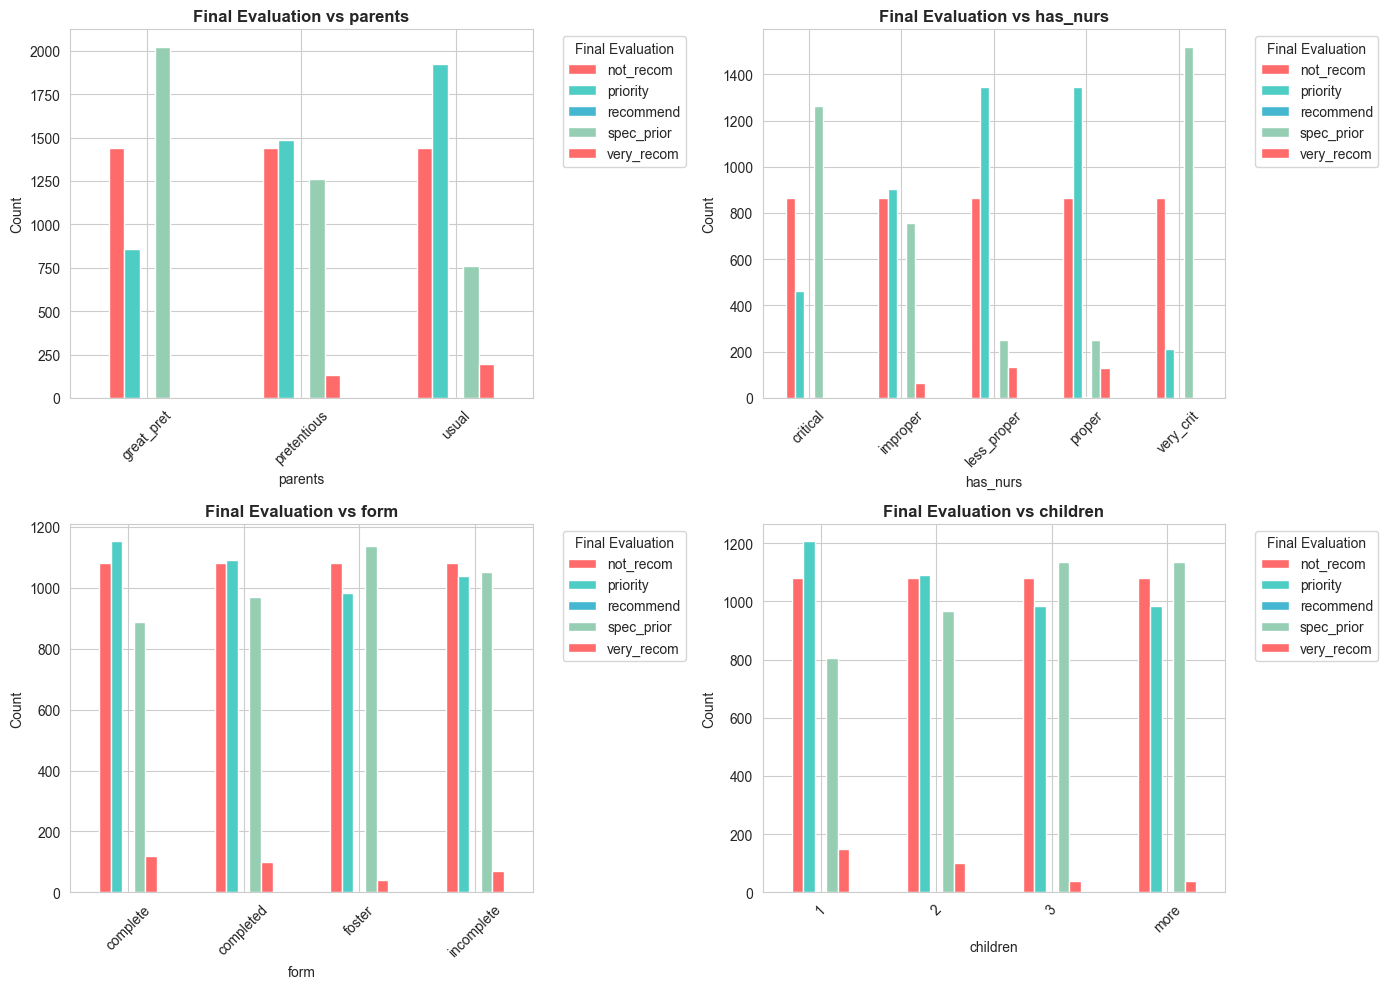

Cross-tabulation: Final Evaluation vs Parents
final evaluation  not_recom  priority  recommend  spec_prior  very_recom
parents                                                                 
great_pret             1440       858          0        2022           0
pretentious            1440      1484          0        1264         132
usual                  1440      1924          2         758         196


In [16]:
# Bivariate analysis - Final Evaluation vs other features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

bivariate_features = ['parents', 'has_nurs', 'form', 'children']

for idx, feature in enumerate(bivariate_features):
    crosstab = pd.crosstab(df_clean[feature], df_clean['final evaluation'])
    crosstab.plot(kind='bar', ax=axes[idx], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    axes[idx].set_title(f'Final Evaluation vs {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Count')
    axes[idx].legend(title='Final Evaluation', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print cross-tabulation for the first feature
print("Cross-tabulation: Final Evaluation vs Parents")
print(pd.crosstab(df_clean['parents'], df_clean['final evaluation']))

## Section 7: Multivariate Visualizations

Create faceted visualizations to explore relationships among multiple variables.

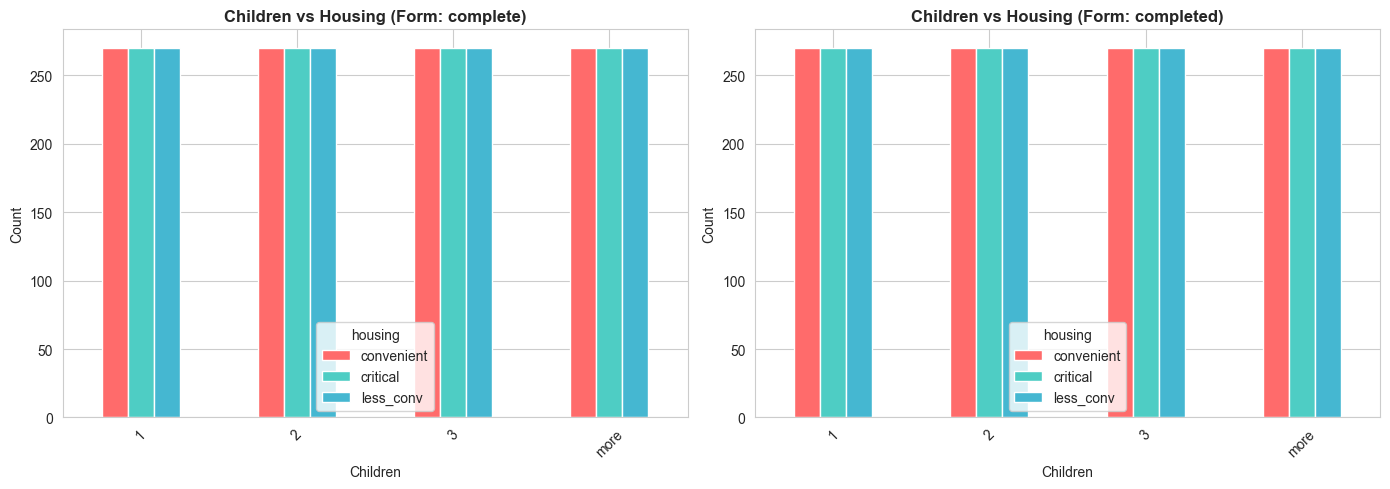

Distribution of Final Evaluation by Children and Housing:
final evaluation     not_recom  priority  recommend  spec_prior  very_recom
children housing                                                           
1        convenient        360       454          2         196          68
         critical          360       340          0         360          20
         less_conv         360       412          0         248          60
2        convenient        360       412          0         248          60
         critical          360       304          0         416           0
         less_conv         360       376          0         304          40
3        convenient        360       376          0         304          40
         critical          360       304          0         416           0
         less_conv         360       304          0         416           0
more     convenient        360       376          0         304          40
         critical          360

In [17]:
# Multivariate analysis - Faceted plots
# Create a faceted visualization of Children vs Housing by Form
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

forms = df_clean['form'].unique()[:2]  # Use first two forms
for idx, form in enumerate(forms):
    subset = df_clean[df_clean['form'] == form]
    crosstab = pd.crosstab(subset['children'], subset['housing'])
    crosstab.plot(kind='bar', ax=axes[idx], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[idx].set_title(f'Children vs Housing (Form: {form})', fontweight='bold')
    axes[idx].set_xlabel('Children')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Distribution of Final Evaluation by Children and Housing
print("Distribution of Final Evaluation by Children and Housing:")
print(pd.crosstab([df_clean['children'], df_clean['housing']], df_clean['final evaluation']))

## Section 8: Correlation Analysis

Calculate and visualize associations between features using label encoding and heatmaps.

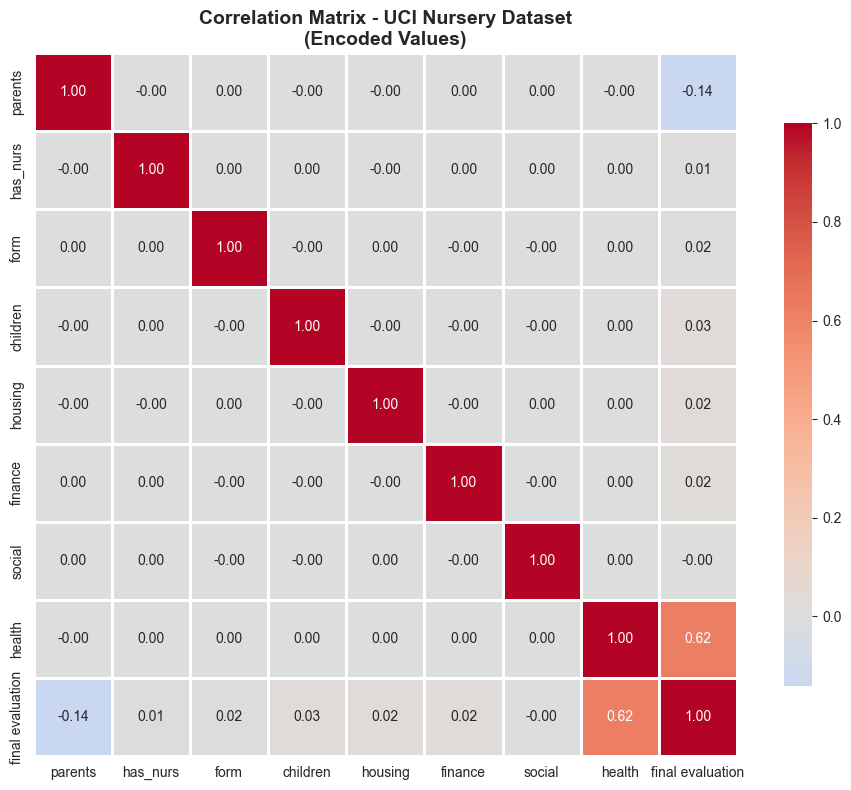

Correlation with Final Evaluation:
final evaluation    1.000000e+00
health              6.179096e-01
children            3.119659e-02
housing             2.468133e-02
finance             2.015222e-02
form                1.871795e-02
has_nurs            8.347501e-03
social             -2.549185e-16
parents            -1.415160e-01
Name: final evaluation, dtype: float64


In [18]:
# Encode categorical variables for correlation analysis
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()
label_encoders = {}

for column in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - UCI Nursery Dataset\n(Encoded Values)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Print correlation with final evaluation
print("Correlation with Final Evaluation:")
print(correlation_matrix['final evaluation'].sort_values(ascending=False))

## Section 9: Interactive Visualizations with Plotly

Create interactive visualizations for better exploration of the data.

In [19]:
# Interactive pie chart for Final Evaluation distribution
fig1 = px.pie(df_clean, names='final evaluation', 
              title='Distribution of Final Evaluation (Interactive)',
              color_discrete_sequence=px.colors.qualitative.Set2)
fig1.show()

# Interactive sunburst chart showing hierarchy
fig2 = px.sunburst(df_clean, path=['parents', 'has_nurs', 'final evaluation'],
                    title='Hierarchical View: Parents -> Has Nursery -> Final Evaluation',
                    color_discrete_sequence=px.colors.qualitative.Set3)
fig2.show()

# Interactive bar chart for multiple features
fig3 = px.histogram(df_clean, x='children', color='final evaluation',
                    title='Distribution of Children by Final Evaluation',
                    barmode='group', category_orders={'children': sorted(df_clean['children'].unique())})
fig3.update_layout(width=900, height=500)
fig3.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Section 10: Key Insights and Summary

### Dataset Overview
- **Total Records**: The UCI Nursery dataset contains nursery class evaluation data
- **Features**: 9 categorical features including parents, nursery form, children, housing, finance, social, health, and final evaluation
- **Target Variable**: Final Evaluation (recommendation status)

### Key Findings

1. **Final Evaluation Distribution**: The target variable shows the distribution of different recommendation classes (recommend, priority, not_recom, very_recom)

2. **Parental Status Impact**: Different parental statuses show varying patterns in nursery recommendations

3. **Feature Relationships**: Strong associations exist between features like housing, finance, and the final evaluation outcome

4. **Data Quality**: No missing values detected; data is clean and ready for analysis

### Recommendations for Further Analysis
- Consider feature engineering for classification tasks
- Explore feature importance for prediction models
- Analyze rare categories separately
- Consider stratified sampling for balanced training sets